# Cost-Sensitive Learning

<img src="image/cost-sensitive-1.png" width="1600">

<img src="image/cost-sensitive-2.png" width="1600">

<img src="image/cost-sensitive-3.png" width="1600">

<img src="image/cost-sensitive-4.png" width="1600">

<img src="image/cost-sensitive-5.png" width="1600">

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

In [2]:
X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],   # 95% class 0, 5% class 1
    class_sep=1.0,
    random_state=42
)

print("Class counts:", np.bincount(y))

Class counts: [1893  107]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Train counts:", np.bincount(y_train))
print("Test  counts:", np.bincount(y_test))

Train counts: [1420   80]
Test  counts: [473  27]


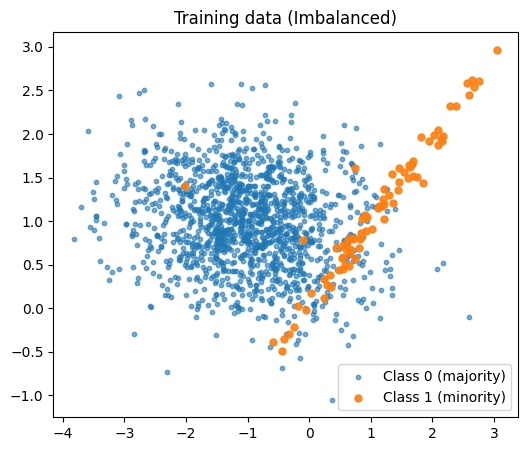

In [4]:
plt.figure(figsize=(6,5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], s=10, alpha=0.6, label="Class 0 (majority)")
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], s=25, alpha=0.9, label="Class 1 (minority)")
plt.title("Training data (Imbalanced)")
plt.legend()
plt.show()

In [5]:
baseline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_lr.fit(X_train, y_train)
y_pred_base = baseline_lr.predict(X_test)


cost_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight={0: 1, 1: 10},  # cost-sensitive
        max_iter=1000,
        random_state=42
    ))
])

cost_lr.fit(X_train, y_train)
y_pred_cost = cost_lr.predict(X_test)

In [6]:
from sklearn.metrics import precision_score, recall_score

def pr_acc(y_true, y_pred, name):
    p = precision_score(y_true, y_pred, average="macro")
    r = recall_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    print(f"{name:35s}  Precision(macro): {p:.4f}  Recall(macro): {r:.4f}  Accuracy: {acc:.4f}")

pr_acc(y_test, y_pred_base, "Baseline Logistic Regression")
pr_acc(y_test, y_pred_cost, "Cost-Sensitive Logistic Regression")

Baseline Logistic Regression         Precision(macro): 0.6858  Recall(macro): 0.5852  Accuracy: 0.9420
Cost-Sensitive Logistic Regression   Precision(macro): 0.6372  Recall(macro): 0.8646  Accuracy: 0.8760


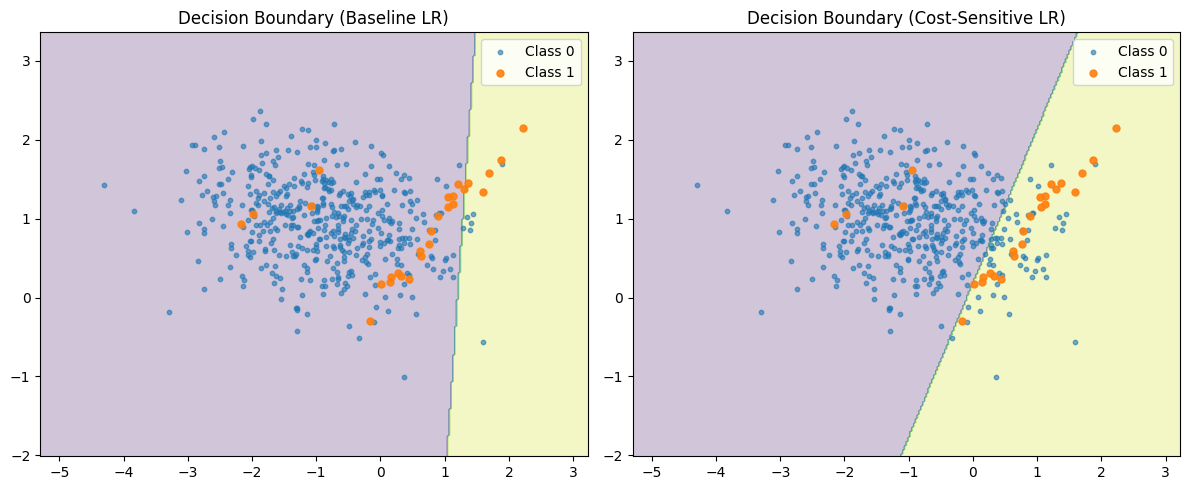

In [7]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[y==0, 0], X[y==0, 1], s=10, alpha=0.6, label="Class 0")
    ax.scatter(X[y==1, 0], X[y==1, 1], s=25, alpha=0.9, label="Class 1")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(baseline_lr, X_test, y_test, axes[0],
                       "Decision Boundary (Baseline LR)")

plot_decision_boundary(cost_lr, X_test, y_test, axes[1],
                       "Decision Boundary (Cost-Sensitive LR)")

plt.tight_layout()
plt.show()